# Подбор перспективной ниши для Ozon/WB — товары для дома/уюта

Проект отрабатывает полный цикл поиска товара под маркетплейс: от сырых данных аналитики до готового кандидата с посчитанной юнит-экономикой и черновым УТП.

**О данных:** данные синтетические — сгенерированы по структуре реальной выгрузки MPSTATS, с реалистичным распределением спроса (не равномерным, а с длинным хвостом — как в жизни: у большинства карточек низкий оборот, у нескольких высокий). Доступа к платной аналитике на момент подготовки не было. Код написан так, что при подключении реального экспорта из MPSTATS меняется один блок — источник данных, вся остальная логика фильтрации, сравнения площадок и юнит-экономики отработает без изменений.

## 1. Подготовка данных

Генерируем датасет по структуре, аналогичной выгрузке MPSTATS: 60 карточек Ozon + 60 карточек Wildberries, ниша «товары для дома/уюта».

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
np.random.seed(42)  # фиксируем, чтобы результаты были воспроизводимы при каждом запуске

subcategories = [
    'Пледы', 'Подсвечники', 'Вазы', 'Ароматизаторы для дома',
    'Декоративные подушки', 'Текстильные корзины-органайзеры',
    'Настенный декор', 'Шторы и тюль', 'Ковры и коврики', 'Постельное бельё'
]

def generate_marketplace_data(marketplace, n=60):
    rows = []
    for i in range(n):
        subcat = np.random.choice(subcategories)
        price = int(np.random.uniform(400, 6500))
        orders_30d = int(np.random.gamma(shape=2.0, scale=40))
        revenue_30d = int(price * orders_30d * np.random.uniform(0.9, 1.1))
        buyout_percent = round(np.random.uniform(35, 92), 1)
        rating = round(np.random.uniform(3.8, 5.0), 1)
        reviews_count = int(orders_30d * np.random.uniform(0.5, 3.0))
        seasonality_index = round(np.random.uniform(0.7, 1.8), 2)
        sellers_count = int(np.random.uniform(1, 40))

        rows.append({
            'article': f'{marketplace[:2].upper()}-{100000 + i}',
            'name': f'{subcat} — модель {i+1}',
            'category': 'Товары для дома',
            'subcategory': subcat,
            'marketplace': marketplace,
            'price': price,
            'orders_30d': orders_30d,
            'revenue_30d': revenue_30d,
            'buyout_percent': buyout_percent,
            'rating': rating,
            'reviews_count': reviews_count,
            'seasonality_index': seasonality_index,
            'sellers_count': sellers_count,
        })
    return pd.DataFrame(rows)

df_ozon = generate_marketplace_data('Ozon', n=60)
df_wb = generate_marketplace_data('Wildberries', n=60)
df_all = pd.concat([df_ozon, df_wb], ignore_index=True)

print(df_all.shape)
df_all.info()

(120, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   article            120 non-null    object 
 1   name               120 non-null    object 
 2   category           120 non-null    object 
 3   subcategory        120 non-null    object 
 4   marketplace        120 non-null    object 
 5   price              120 non-null    int64  
 6   orders_30d         120 non-null    int64  
 7   revenue_30d        120 non-null    int64  
 8   buyout_percent     120 non-null    float64
 9   rating             120 non-null    float64
 10  reviews_count      120 non-null    int64  
 11  seasonality_index  120 non-null    float64
 12  sellers_count      120 non-null    int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 12.3+ KB


## 2. Параллельный SQL-пайплайн

Вся логика ниже продублирована на SQL (через SQLite) и на pandas — для тренировки и для того, чтобы показать эквивалентность обоих подходов.

In [2]:
import sqlite3

conn = sqlite3.connect('product.db')

df_all.to_sql(
    'df_all',
    conn,
    if_exists='replace',
    index=False
)

pd.set_option('display.float_format', '{:,.2f}'.format)

## 3. Фильтрация ниши

**Вопрос анкеты:** *«Ты ищешь новый товар через аналитику Ozon. С чего начинаешь и по каким метрикам/фильтрам отбираешь нишу? Назови конкретные ориентиры (чек, оборот/выручка карточки, % выкупа, сезонность).»*

Пороги фильтра не выбираются произвольно — они считаются от реального распределения данных (квантили), чтобы отражать структуру именно этого рынка.

In [3]:
df_all[['price', 'revenue_30d', 'buyout_percent', 'sellers_count']].describe()

,price,revenue_30d,buyout_percent,sellers_count
count,120.00,120.00,120.00,120.00
mean,"3,479.30","291,265.62",63.23,17.88
std,"1,713.72","284,922.68",16.79,10.99
min,430.00,"4,642.00",35.50,1.00
25%,"1,946.00","92,953.00",47.10,9.00
50%,"3,450.50","186,051.00",65.80,17.00
75%,"4,897.75","390,377.50",77.90,27.00
max,"6,447.00","1,409,938.00",91.20,39.00


In [4]:
q25_price = df_all['price'].quantile(0.25)
q75_price = df_all['price'].quantile(0.75)
q25_revenue = df_all['revenue_30d'].quantile(0.25)
median_buyout = df_all['buyout_percent'].median()
median_sellers_count = df_all['sellers_count'].median()

print('Диапазон цены:', q25_price, '-', q75_price)
print('25% квантиль выручки:', q25_revenue)
print('Медиана % выкупа:', median_buyout)
print('Медиана числа продавцов:', median_sellers_count)

Диапазон цены: 1946.0 - 4897.75
25% квантиль выручки: 92953.0
Медиана % выкупа: 65.8
Медиана числа продавцов: 17.0


**Логика порогов:**
- **Цена** — диапазон 25%–75% процентиль (двусторонний): и слишком дёшево, и слишком дорого — разные риски (низкая маржа на логистике против недоверие к новой карточке без репутации).
- **Оборот** — отсекаем значения ниже 25% процентиля ( статистическии слабый, непроверенный спрос)
- **% выкупа** — берем верхнюю границу медианного значения, выбрасываем нижнюю половину по качеству спроса
- **Число продавцов** — только верхняя граница (медиана): низкая конкуренция никогда не проблема, отсекаем перегретые ниши.

Сортировка результата — по обороту, по убыванию.

In [5]:
sql_query = f"""
DROP VIEW IF EXISTS df_filtered_view;

CREATE VIEW df_filtered_view AS
SELECT *
FROM df_all
WHERE price BETWEEN {q25_price} AND {q75_price}
  AND revenue_30d >= {q25_revenue}
  AND buyout_percent >= {median_buyout}
  AND sellers_count <= {median_sellers_count}
"""
conn.executescript(sql_query)

df_filtered_sql = pd.read_sql_query(
    "SELECT * FROM df_filtered_view ORDER BY revenue_30d DESC",
    conn
)
df_filtered_sql

,article,name,category,subcategory,marketplace,price,orders_30d,revenue_30d,buyout_percent,rating,reviews_count,seasonality_index,sellers_count
0,WI-100005,Ароматизаторы для дома — модель 6,Товары для дома,Ароматизаторы для дома,Wildberries,4340,253,1066418,91.20,4.50,276,0.81,6
1,WI-100044,Пледы — модель 45,Товары для дома,Пледы,Wildberries,2851,269,841169,78.80,4.30,417,1.51,10
2,OZ-100036,Ароматизаторы для дома — модель 37,Товары для дома,Ароматизаторы для дома,Ozon,3910,186,733895,88.70,4.30,539,1.70,8
3,OZ-100051,Пледы — модель 52,Товары для дома,Пледы,Ozon,2698,213,562374,82.30,4.50,140,0.74,6
4,WI-100035,Ароматизаторы для дома — модель 36,Товары для дома,Ароматизаторы для дома,Wildberries,4786,100,494266,88.40,4.70,103,0.73,11
5,WI-100031,Пледы — модель 32,Товары для дома,Пледы,Wildberries,2038,251,474641,82.60,5.00,455,0.89,11
6,OZ-100006,Настенный декор — модель 7,Товары для дома,Настенный декор,Ozon,3577,81,316697,69.60,4.10,100,0.88,1
7,OZ-100003,Декоративные подушки — модель 4,Товары для дома,Декоративные подушки,Ozon,4106,60,224929,89.10,5.00,151,1.04,4
8,WI-100045,Вазы — модель 46,Товары для дома,Вазы,Wildberries,3250,49,170487,75.80,4.50,58,1.70,2
9,WI-100037,Пледы — модель 38,Товары для дома,Пледы,Wildberries,3422,39,141975,80.60,4.60,46,1.35,15


In [6]:
df_filtered = df_all[
    (df_all['price'].between(q25_price, q75_price)) &
    (df_all['revenue_30d'] >= q25_revenue) &
    (df_all['buyout_percent'] >= median_buyout) &
    (df_all['sellers_count'] <= median_sellers_count)
].sort_values('revenue_30d', ascending=False)

print('SQL и pandas дают одинаковое число строк:', len(df_filtered_sql) == len(df_filtered))
df_filtered

SQL и pandas дают одинаковое число строк: True


,article,name,category,subcategory,marketplace,price,orders_30d,revenue_30d,buyout_percent,rating,reviews_count,seasonality_index,sellers_count
65,WI-100005,Ароматизаторы для дома — модель 6,Товары для дома,Ароматизаторы для дома,Wildberries,4340,253,1066418,91.20,4.50,276,0.81,6
104,WI-100044,Пледы — модель 45,Товары для дома,Пледы,Wildberries,2851,269,841169,78.80,4.30,417,1.51,10
36,OZ-100036,Ароматизаторы для дома — модель 37,Товары для дома,Ароматизаторы для дома,Ozon,3910,186,733895,88.70,4.30,539,1.70,8
51,OZ-100051,Пледы — модель 52,Товары для дома,Пледы,Ozon,2698,213,562374,82.30,4.50,140,0.74,6
95,WI-100035,Ароматизаторы для дома — модель 36,Товары для дома,Ароматизаторы для дома,Wildberries,4786,100,494266,88.40,4.70,103,0.73,11
91,WI-100031,Пледы — модель 32,Товары для дома,Пледы,Wildberries,2038,251,474641,82.60,5.00,455,0.89,11
6,OZ-100006,Настенный декор — модель 7,Товары для дома,Настенный декор,Ozon,3577,81,316697,69.60,4.10,100,0.88,1
3,OZ-100003,Декоративные подушки — модель 4,Товары для дома,Декоративные подушки,Ozon,4106,60,224929,89.10,5.00,151,1.04,4
105,WI-100045,Вазы — модель 46,Товары для дома,Вазы,Wildberries,3250,49,170487,75.80,4.50,58,1.70,2
97,WI-100037,Пледы — модель 38,Товары для дома,Пледы,Wildberries,3422,39,141975,80.60,4.60,46,1.35,15


**Экономический вывод шага:** из 120 карточек фильтр оставил 13 кандидатов, статистически заслуживающих ручного рассмотрения — это и есть цель фильтрации: дёшево (секунды вычислений) отсеять заведомо слабых кандидатов до того, как тратится дорогой ресурс

## 4. Агрегация по подкатегориям

Переход с уровня «отдельная карточка» на уровень «ниша целиком» — отдельная карточка может быть случайностью, средние показатели по нескольким карточкам подкатегории уже сигнал устойчивости спроса.

In [7]:
sql_query = """
SELECT
  subcategory,
  COUNT(DISTINCT article) AS count_article,
  AVG(price) AS avg_price,
  AVG(revenue_30d) AS avg_rev_30d,
  AVG(buyout_percent) AS avg_bp
FROM df_filtered_view
GROUP BY subcategory
ORDER BY AVG(revenue_30d) DESC
"""
df = pd.read_sql_query(sql_query, conn)
df

,subcategory,count_article,avg_price,avg_rev_30d,avg_bp
0,Ароматизаторы для дома,4,"3,900.50","608,582.50",83.78
1,Пледы,4,"2,752.25","505,039.75",81.07
2,Настенный декор,2,"3,974.00","226,127.50",71.30
3,Декоративные подушки,1,"4,106.00","224,929.00",89.10
4,Вазы,1,"3,250.00","170,487.00",75.80
5,Текстильные корзины-органайзеры,1,"2,797.00","100,462.00",80.30


In [8]:
df_indicators = (
    df_filtered
    .groupby('subcategory')
    .agg(
        count_article=('article', 'count'),
        avg_price=('price', 'mean'),
        avg_rev_30d=('revenue_30d', 'mean'),
        avg_bp=('buyout_percent', 'mean'),
    )
    .sort_values('avg_rev_30d', ascending=False)
)

df_indicators

,count_article,avg_price,avg_rev_30d,avg_bp
subcategory,,,,
Ароматизаторы для дома,4,"3,900.50","608,582.50",83.78
Пледы,4,"2,752.25","505,039.75",81.07
Настенный декор,2,"3,974.00","226,127.50",71.30
Декоративные подушки,1,"4,106.00","224,929.00",89.10
Вазы,1,"3,250.00","170,487.00",75.80
Текстильные корзины-органайзеры,1,"2,797.00","100,462.00",80.30


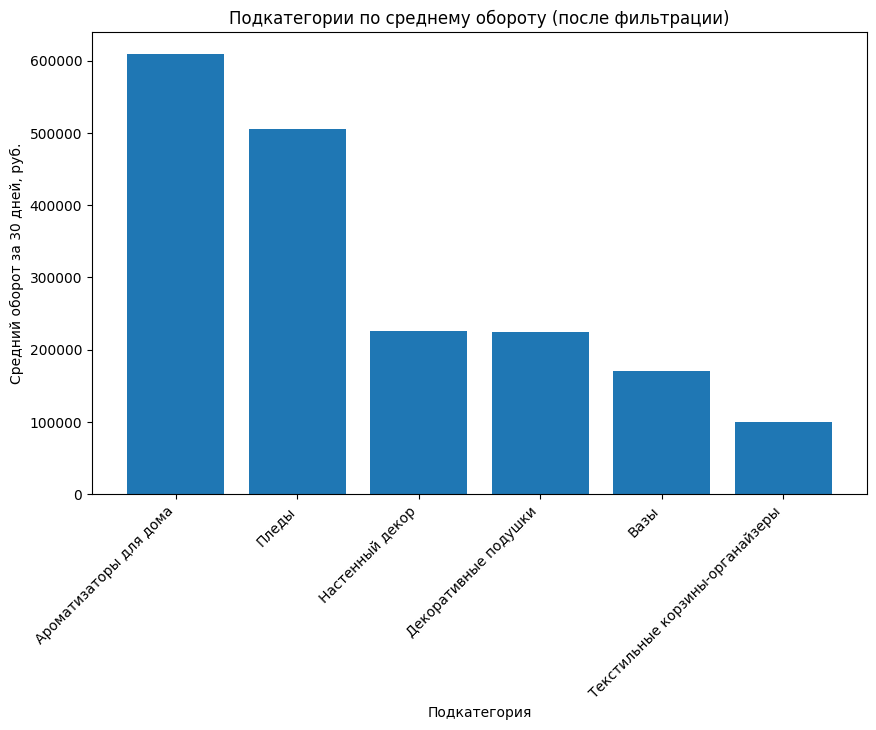

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(df_indicators.index, df_indicators['avg_rev_30d'])
plt.title('Подкатегории по среднему обороту (после фильтрации)')
plt.xlabel('Подкатегория')
plt.ylabel('Средний оборот за 30 дней, руб.')
plt.xticks(rotation=45, ha='right')
plt.show()

**Наблюдение:** Ароматизаторы для дома и Пледы лидируют по обороту, но именно они наиболее заметны в топе — конкуренция за внимание покупателя там выше. Вазы и Текстильные корзины-органайзеры — ниши с меньшим, но всё ещё прошедшим фильтр оборотом (выше 25% процентиля по рынку в целом), потенциально более свободные от внимания крупных игроков.

## 5. Сравнение Ozon vs Wildberries

Поиск незанятой площадки: если ниша сильна на одной площадке и слаба на другой — это либо окно возможностей, либо сигнал проверить нишу на слабой площадке отдельно.

In [10]:
revenue_by_subcat_market = (
    df_all
    .groupby(['subcategory', 'marketplace'])
    .agg(total_revenue=('revenue_30d', 'sum'))
    .reset_index()
)

pivot_revenue = revenue_by_subcat_market.pivot(
    index='subcategory',
    columns='marketplace',
    values='total_revenue'
).fillna(0)

pivot_revenue['разница'] = pivot_revenue['Ozon'] - pivot_revenue['Wildberries']
pivot_revenue['соотношение'] = (pivot_revenue['Ozon'] / pivot_revenue['Wildberries']).round(2)
pivot_revenue = pivot_revenue.sort_values('разница', ascending=False)

pivot_revenue.style.format({
    'Ozon': '{:,.0f}',
    'Wildberries': '{:,.0f}',
    'разница': '{:,.0f}',
    'соотношение': '{:.2f}'
})

marketplace,Ozon,Wildberries,разница,соотношение
subcategory,,,,
Вазы,"4,345,376","383,805","3,961,571",11.32
Настенный декор,"3,629,287","1,932,797","1,696,490",1.88
Постельное бельё,"1,364,576","754,549","610,027",1.81
Декоративные подушки,"1,222,768","1,365,335","-142,567",0.90
Ковры и коврики,"1,458,814","1,701,948","-243,134",0.86
Подсвечники,"403,797","979,548","-575,751",0.41
Текстильные корзины-органайзеры,"337,823","919,135","-581,312",0.37
Пледы,"2,529,249","3,222,537","-693,288",0.78
Шторы и тюль,"342,153","2,355,871","-2,013,718",0.15


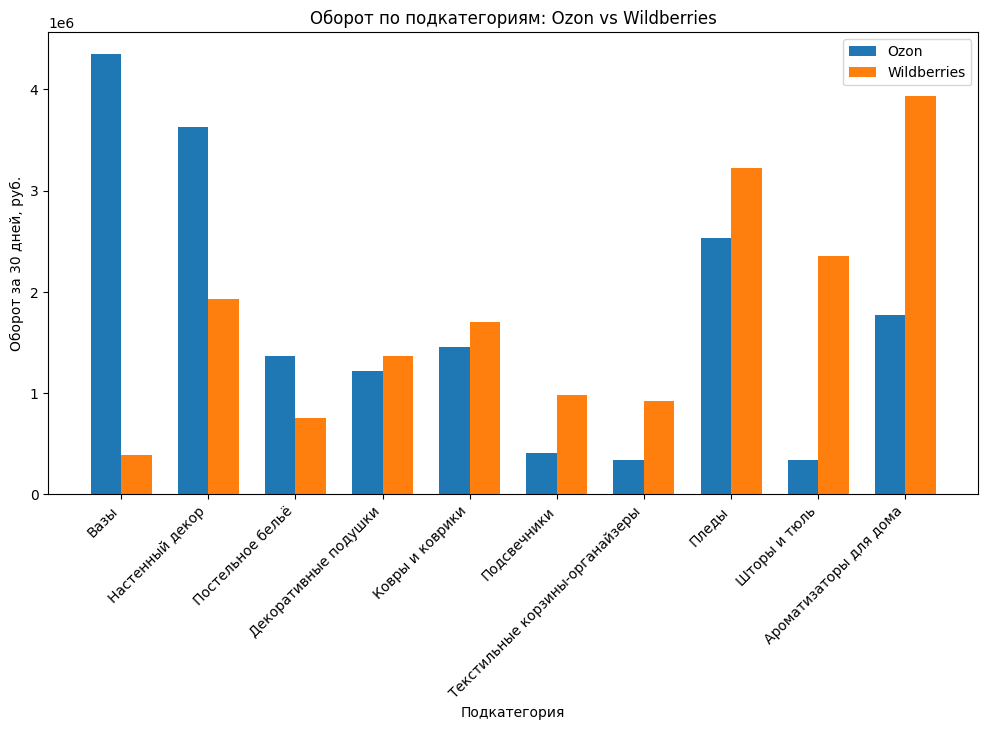

In [11]:
x = np.arange(len(pivot_revenue))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, pivot_revenue['Ozon'], width, label='Ozon')
plt.bar(x + width/2, pivot_revenue['Wildberries'], width, label='Wildberries')

plt.title('Оборот по подкатегориям: Ozon vs Wildberries')
plt.xlabel('Подкатегория')
plt.ylabel('Оборот за 30 дней, руб.')
plt.xticks(x, pivot_revenue.index, rotation=45, ha='right')
plt.legend()
plt.show()

**Экономический вывод:** фокус на двух ранее отобранных потенциальных нишах —

- **Вазы** — оборот почти полностью сосредоточен на Ozon, на Wildberries представленность минимальна → низкая точка входа именно на WB (окно возможностей, если органический спрос там подтвердится).
- **Текстильные корзины-органайзеры** — обратная картина: основной оборот на Wildberries, Ozon недопредставлен → аналогичное окно, но на другой площадке.

Обе ниши интересны, но по разным причинам — дальше юнит-экономика покажет, какая выгоднее с точки зрения запаса маржи.

## 6. Юнит-экономика

**Вопрос анкеты:** *«Как ты считаешь юнит-экономику перед закупкой: что берёшь за себестоимость, что учитываешь, при какой рентабельности товар «проходит»?»*

Логика — не «купил дешевле, продал дороже», а обратная: цену продажи диктует рынок (уже сложившиеся цены конкурентов), поэтому считаем максимальную закупочную цену, при которой сохраняется целевая рентабельность.

In [12]:
def calc_max_purchase_price(
    sale_price,
    target_margin_pct,
    commission_pct,
    ads_pct,
    logistics_per_unit,
    storage_per_unit,
    defect_rate_pct=0,
    other_costs_pct=0,
):
    """Возвращает максимальную закупочную цену под целевую рентабельность."""
    commission = sale_price * commission_pct / 100
    ads = sale_price * ads_pct / 100
    defect_loss = sale_price * defect_rate_pct / 100
    other = sale_price * other_costs_pct / 100
    target_profit = sale_price * target_margin_pct / 100

    max_purchase_price = (
        sale_price
        - commission
        - ads
        - defect_loss
        - other
        - target_profit
        - logistics_per_unit
        - storage_per_unit
    )
    return round(max_purchase_price, 2)


# Комиссия площадки взята на уровне 40% — по актуальным тарифам Ozon 2026 года
# для среднего ценового сегмента (1500-5000₽), а не устаревшие 15%

# Вазы — хрупкий товар, закладываем риск боя/брака при доставке
vases_price = df_indicators.loc['Вазы', 'avg_price']
vases_max_purchase = calc_max_purchase_price(
    sale_price=vases_price,
    target_margin_pct=25,
    commission_pct=40,
    ads_pct=8,
    logistics_per_unit=150,      # выше стандартной — хрупкая упаковка объёмнее/тяжелее
    storage_per_unit=15,
    defect_rate_pct=7,           # закладываем риск боя при доставке
)

# Текстильные корзины-органайзеры — мягкий товар, риска боя нет
baskets_price = df_indicators.loc['Текстильные корзины-органайзеры', 'avg_price']
baskets_max_purchase = calc_max_purchase_price(
    sale_price=baskets_price,
    target_margin_pct=25,
    commission_pct=40,
    ads_pct=8,
    logistics_per_unit=90,
    storage_per_unit=15,
    defect_rate_pct=0,
)

vases_margin_pct = round(vases_max_purchase / vases_price * 100, 1)
baskets_margin_pct = round(baskets_max_purchase / baskets_price * 100, 1)

print(f'Вазы — цена продажи: {vases_price:.0f} ₽, макс. закупка: {vases_max_purchase} ₽ ({vases_margin_pct}% от цены)')
print(f'Текстильные корзины — цена продажи: {baskets_price:.0f} ₽, макс. закупка: {baskets_max_purchase} ₽ ({baskets_margin_pct}% от цены)')

Вазы — цена продажи: 3250 ₽, макс. закупка: 485.0 ₽ (14.9% от цены)
Текстильные корзины — цена продажи: 2797 ₽, макс. закупка: 650.19 ₽ (23.2% от цены)


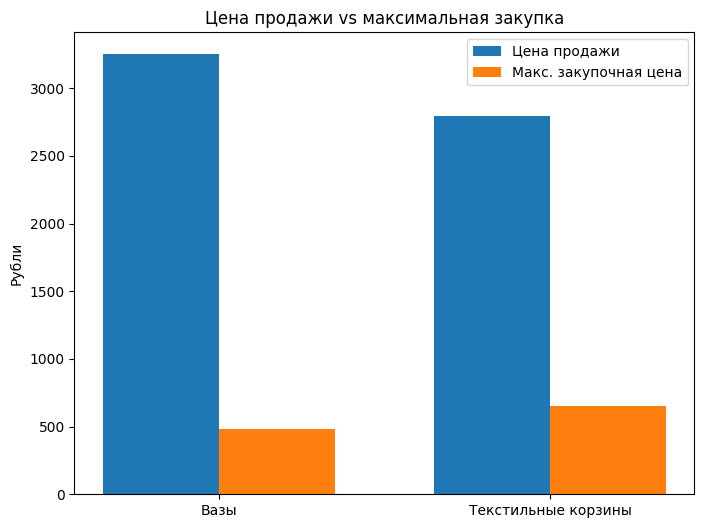

In [13]:
labels = ['Вазы', 'Текстильные корзины']
sale_prices = [vases_price, baskets_price]
max_purchases = [vases_max_purchase, baskets_max_purchase]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, sale_prices, width, label='Цена продажи')
plt.bar(x + width/2, max_purchases, width, label='Макс. закупочная цена')
plt.title('Цена продажи vs максимальная закупка')
plt.ylabel('Рубли')
plt.xticks(x, labels)
plt.legend()
plt.show()

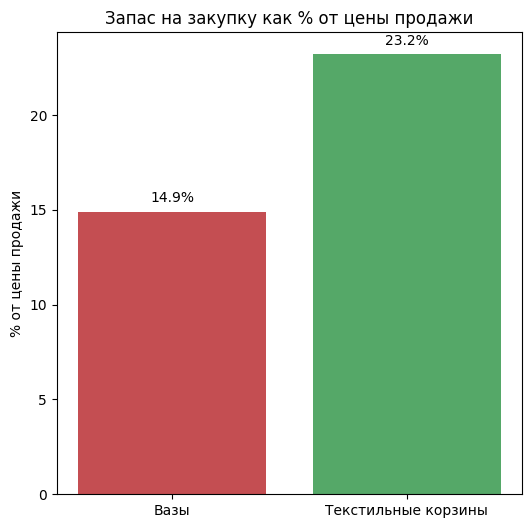

In [14]:
# Сравнение в % от цены продажи — так виден реальный запас прочности,
# независимо от разной цены товаров (более честное сравнение, чем в рублях)
plt.figure(figsize=(6, 6))
bars = plt.bar(labels, [vases_margin_pct, baskets_margin_pct], color=['#C44E52', '#55A868'])
plt.title('Запас на закупку как % от цены продажи')
plt.ylabel('% от цены продажи')
for bar, val in zip(bars, [vases_margin_pct, baskets_margin_pct]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val}%', ha='center')
plt.show()

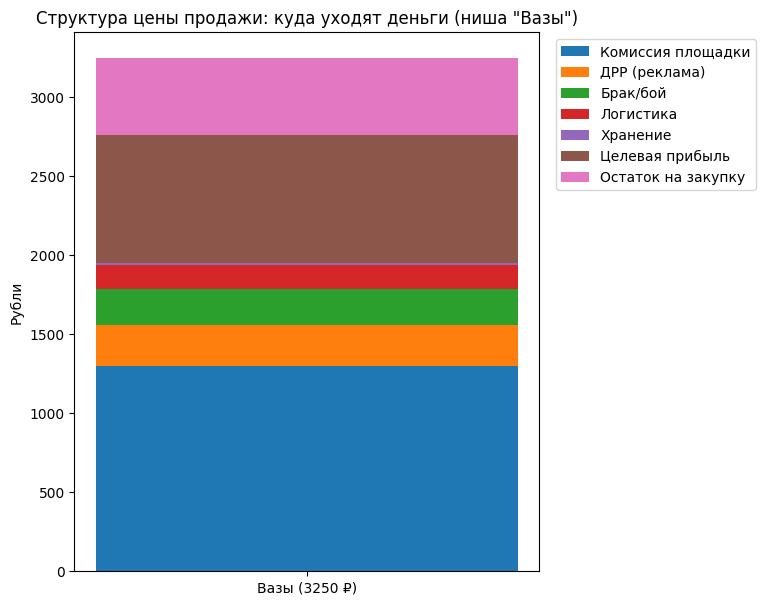

In [15]:
commission = vases_price * 0.40
ads = vases_price * 0.08
defect = vases_price * 0.07
target_profit = vases_price * 0.25
logistics = 150
storage = 15
remaining = vases_max_purchase

components = [
    ('Комиссия площадки', commission),
    ('ДРР (реклама)', ads),
    ('Брак/бой', defect),
    ('Логистика', logistics),
    ('Хранение', storage),
    ('Целевая прибыль', target_profit),
    ('Остаток на закупку', remaining),
]

plt.figure(figsize=(6, 7))
bottom = 0
for label, value in components:
    plt.bar('Вазы (3250 ₽)', value, bottom=bottom, label=label)
    bottom += value

plt.title('Структура цены продажи: куда уходят деньги (ниша "Вазы")')
plt.ylabel('Рубли')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

**Экономический вывод:** сравнивать нужно не рубли, а процент от цены продажи. У Ваз запас на закупку почти на треть меньше (14.9% против 23.2% у Корзин) — из-за более высокой логистики (хрупкая упаковка) и заложенного риска боя. Это делает нишу «Вазы» более чувствительной к отклонению факта от плана: если реальный % брака окажется выше заложенных 7%, ниша рискует уйти в минус. У Корзин больший буфер прочности при сопоставимом уровне спроса.

**Практический следующий шаг:** проверить на 1688, реально ли найти вазу (керамика/стекло) с доставкой до склада дешевле ~485₽ — бюджет жёсткий для хрупкого товара. Для Корзин бюджет мягче (~650₽), там выше шансы уложиться.

## 8. УТП и отстройка

**Вопрос анкеты:** *«Что для тебя «отстройка» и «УТП» на практике? Возьми конкретную нишу и покажи, чем бы ты в ней отстроился.»*

### Вазы
Керамическая ваза с ударопрочным силиконовым основанием (снижает риск боя при падении/неаккуратной транспортировке) + встроенный органайзер-разделитель под сухоцветы или ветки (решает частую жалобу «цветы падают, композиция разваливается») + модульность — 3 размера в одной товарной линейке для комплексной продажи.

Комбинация из трёх практических доработок одновременно решает главный операционный риск ниши (бой при доставке — прямое снижение % брака, заложенного в юнит-экономику) и создаёт причину для покупки набора, а не одной единицы — повышает средний чек.

### Текстильные корзины-органайзеры
Усиленный каркас (не теряет форму при неполной загрузке — частая жалоба на дешёвые аналоги) + двусторонняя расцветка (можно перевернуть под интерьер) + встроенные ручки-стяжки для переноски.

Решает функциональную проблему (потеря формы) плюс добавляет два практических преимущества — три отличия в одном продукте, а не косметическое изменение цвета.

### Общий принцип
В обеих нишах отстройка построена на решении конкретных, наблюдаемых проблем товара, а не на визуальных отличиях — это одновременно снижает операционный риск (меньше возвратов/брака) и создаёт содержательное УТП для карточки.

## 10. Итоговый вывод по поиску ниши

Из 120 карточек в исходных данных статистически обоснованный фильтр (по квантилям цены/оборота/% выкупа/конкуренции, откалиброванным под сам датасет, а не заданным произвольно) оставил короткий список кандидатов. Из него для дальнейшей проработки выбраны две ниши:

| Критерий | Вазы | Текстильные корзины-органайзеры |
|---|---|---|
| Оборот в короткому списке | Ниже среднего по списку, но выше 25% процентиля всего рынка | Ниже среднего по списку, но выше 25% процентиля всего рынка |
| Точка входа | Низкая на Wildberries (оборот сосредоточен на Ozon) | Низкая на Ozon (оборот сосредоточен на Wildberries) |
| Запас маржи (юнит-экономика) | 14.9% от цены продажи | 23.2% от цены продажи |
| Операционный риск | Хрупкость — бой при доставке | Минимальный, мягкий товар |
| Рекомендация | На рассмотрении — жёсткий бюджет закупки (~485₽), нужна проверка у фабрики | Приоритетнее для первой закупки — больший буфер прочности |

**Итоговая рекомендация:** начать переговоры с фабриками на 1688 с ниши **Текстильные корзины-органайзеры** (Ozon) — она даёт больший запас маржи и не несёт риска боя при доставке. Нишу **Вазы** (Wildberries) держать вторым кандидатом — при более тщательной проверке реалистичности закупочного бюджета и стоимости упаковки под хрупкий товар.

Финальное решение о закупке — за собственником; данный вывод и журнал подбора — обоснование для его принятия.